In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE


In [19]:
df = pd.read_csv("../data/city_lifestyle_dataset.csv")

df.head()

df.shape


(300, 10)

In [15]:
df_numeric = df.select_dtypes(include=[np.number])

df_numeric.head()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

In [17]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

X_tsne[:5]

array([[11.241733  , -3.3562706 ],
       [ 9.78201   ,  0.87946266],
       [17.283047  , -1.2637584 ],
       [ 7.3038006 , -7.058923  ],
       [20.082563  ,  1.0286565 ]], dtype=float32)

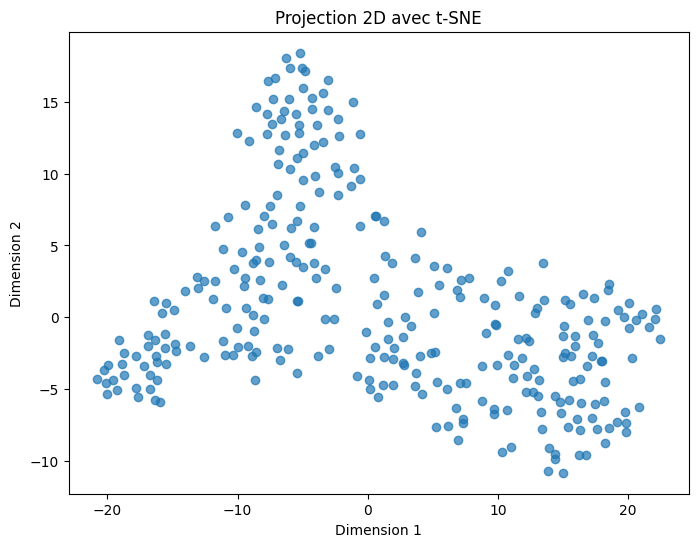

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.7)
plt.title("Projection 2D avec t-SNE")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

# Observation

La projection t-SNE en deux dimensions met en évidence une structuration non aléatoire des données. On observe plusieurs groupes distincts : un cluster compact situé en haut du graphique (Dimension 2 positive), un groupe étalé vers la droite (Dimension 1 positive), ainsi qu’un groupe plus concentré à gauche (Dimension 1 négative).

Ces regroupements suggèrent l’existence de similarités locales entre certaines villes en termes de caractéristiques de style de vie. Les points proches dans l’espace 2D représentent des observations similaires dans l’espace original de grande dimension.

Il est important de noter que t-SNE préserve principalement les relations locales : la distance entre clusters ne reflète pas nécessairement une distance réelle globale, mais la cohérence interne des groupes semble bien capturée.
